# **Importing the Dependencies**

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
#import needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge


# **Data Collection **

In [4]:
# loading the data from csv file to pandas datafram
df=pd.read_csv(r"D:\Courses\DEPI\Technical\Files\car data (1).csv")

# Understanding the data

In [5]:
# inspecting the first 5 rows of the dataframe
df.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
# and the last 5 rows
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [7]:
#and a random sample
df.sample()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
229,i20,2012,3.1,6.79,52132,Diesel,Dealer,Manual,0


In [8]:
# checking the number of rows and columns
df.shape

(301, 9)

In [9]:
# getting some information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


# Preprocessing :

1- Handle Missing Values

2- Encode Categorical Features

3-Remove irrelivent features if needed

3- Split Data into Training and Testing Sets  

In [10]:
# checking the number of missing values
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [11]:
#check for duplicates
df.duplicated().sum()

2

In [12]:
# print them  using keep = false
df[df.duplicated(keep=False)]


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
15,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


In [13]:
# handle them
df = df.drop_duplicates()

In [14]:
# chec k if  they are  handled
df.duplicated().sum()

0

In [15]:
# checking the distribution of categorical data
df.value_counts()

Car_Name           Year  Selling_Price  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  Transmission  Owner
800                2003  0.35           2.28           127000      Petrol     Individual   Manual        0        1
etios gd           2015  4.75           7.85           40000       Diesel     Dealer       Manual        0        1
etios g            2014  4.75           6.76           40000       Petrol     Dealer       Manual        0        1
                         4.10           6.80           39485       Petrol     Dealer       Manual        1        1
etios cross        2015  4.50           7.70           40588       Petrol     Dealer       Manual        0        1
                                                                                                                 ..
Yamaha FZ S V 2.0  2015  0.55           0.84           58000       Petrol     Individual   Manual        0        1
                         0.48           0.84           23000       Petrol    

Encoding the Categorical Data

In [16]:
# encoding "Fuel_Type" Column


# encoding "Seller_Type" Column


# encoding "Transmission" Column
df = pd.get_dummies(df, columns=[
    'Fuel_Type', 'Seller_Type', 'Transmission'
], drop_first=True)

In [17]:
#print the coloum to make sure the encoding is correct
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Owner', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol',
       'Seller_Type_Individual', 'Transmission_Manual'],
      dtype='object')

In [18]:
#check the first rows to see the dataset after encoding
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,ritz,2014,3.35,5.59,27000,0,False,True,False,True
1,sx4,2013,4.75,9.54,43000,0,True,False,False,True
2,ciaz,2017,7.25,9.85,6900,0,False,True,False,True
3,wagon r,2011,2.85,4.15,5200,0,False,True,False,True
4,swift,2014,4.60,6.87,42450,0,True,False,False,True


In [19]:
#check the car informations
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Car_Name                299 non-null    object 
 1   Year                    299 non-null    int64  
 2   Selling_Price           299 non-null    float64
 3   Present_Price           299 non-null    float64
 4   Kms_Driven              299 non-null    int64  
 5   Owner                   299 non-null    int64  
 6   Fuel_Type_Diesel        299 non-null    bool   
 7   Fuel_Type_Petrol        299 non-null    bool   
 8   Seller_Type_Individual  299 non-null    bool   
 9   Transmission_Manual     299 non-null    bool   
dtypes: bool(4), float64(2), int64(3), object(1)
memory usage: 17.5+ KB


# **Splitting the data and Target**

u can also use I loc

X = car_dataset.iloc[:, 2:]  # Select all columns from the 3rd column onwards

(excluding 'Car_Name' and 'Selling_Price')

Y = car_dataset.iloc[:, 1]   # Select the 'Selling_Price' column

In [20]:
#spilt to features and labels first then to train test _ Drop Irrelevant or Redundant Features
X = df.drop(['Car_Name', 'Selling_Price'], axis=1)
Y = df['Selling_Price']

# **Train _ Test _ Split **

In [21]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=30
)

changing the random_state value changes the deterministic shuffle pattern and affects which samples are included in the train and test sets. The specific value itself (e.g., 2 vs. 42) does not matter, as long as you are consistent for reproducibility.

In [22]:
#check the shape of X train _ Xtest _ y test _ y train
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(239, 8)
(60, 8)
(239,)
(60,)


In [23]:
from sklearn.metrics import mean_squared_error  # Import RMSE computation function

def display_results(model):
    # Retrieve the model's intercept (bias term) and coefficients (weights for features)
    coefs = [model.intercept_]  # Add intercept
    coefs += list(model.coef_)  # Add feature coefficients

    # Predict target values using the training dataset روح نفذ المعادله
    #يعني الاول روحت  عملت بريديكت بال train test بتاع ال x
    ytrain_predict = model.predict(X_train)  # Training set predictions يا ترين طلعتي نسبه قد اي
    # Predict target values using the testing dataset
    ytest_predict = model.predict(X_test)   # Testing set predictions يا تست هتطلعي نسبه قد اي
     # هتلاقو شرح ليها اكتر تحت

# mean_squared_error calculates the average squared difference between actual (Y_train) and predicted values (ytrain_predict).
# mean_squared_error is a built-in function provided by the sklearn.metrics  بجبها منين
    # Calculate RMSE for the training predictions ## why ?? ___ To  measure how far off the predictions are from the actual values using Root Mean Squared Error (RMSE).
    train_error = np.sqrt(mean_squared_error(Y_train, ytrain_predict))   ## علشان يحسبها هيحتاج يطرح ال actual _predicit
    # Calculate RMSE for the testing predictions
    test_error = np.sqrt(mean_squared_error(Y_test, ytest_predict))

    # Print RMSE values to assess model performance
    print("Training error (rmse):", train_error)  # Display training RMSE  لو كبير اوي ممكن يبقي underfit
    print("Testing error (rmse):", test_error)    # Display testing RMSE هنا بحسب وبشووفو لو قريب من ال train
    #تبقي ماشي تمام لو  كبير يبقي overfit

    # Scatter plot to compare true values and predictions for both datasets
    plt.scatter(Y_train, ytrain_predict, marker='o', label='Train Predictions')  # Training data scatter plot
    plt.scatter(Y_test, ytest_predict, marker='^', label='Test Predictions')    # Testing data scatter plot

    plt.xlabel('True Values')  # X-axis label
    plt.ylabel('Predictions')  # Y-axis label
    plt.title('True vs Predicted Values')  # Plot title
    plt.legend()  # Add legend to distinguish datasets
    plt.show()  # Display the plot

    # Print the coefficients of the model for interpretation
    print("Coefficients:")
    print(coefs)  # Display intercept and feature coefficients



**Explanation of the Function**
**What Does the Function Do?**

This function checks how well a regression model works by:

Looking at the model’s "rules" (the intercept and coefficients it learned from the data).

Testing how accurate the predictions are for both the training and test data.
Showing a graph to compare actual vs. predicted values.

Printing a list of the model's coefficients to understand which features matter most.

**Steps Taken by the Function**

*Get the Model’s Parameters*


It takes the intercept (a constant the model adds to predictions) and coefficients (the importance of each feature) from the trained model.

*Make Predictions *

It uses the model to predict the outcomes for both the training data (what it learned from) and testing data (new data it hasn’t seen before).

*Calculate Errors*

It calculates how far the predicted values are from the actual values using a metric called Root Mean Squared Error (RMSE).
RMSE tells you how much the model’s predictions are "off" on average.
Plot True vs. Predicted Values

*It creates a scatter plot where:*

Dots represent data points.
Dots closer to a straight line mean better predictions.
Print the Results

*It prints:*
How much error (RMSE) the model has on training and testing data.

The intercept and coefficients so you can understand what the model learned.

**Simple Example Walkthrough**
**Imagine you are trying to predict house prices:**

Intercept: Base price for all houses.

Coefficients: How much factors like the number of rooms or location impact the price.

The function shows:

Intercept and coefficients: "A bigger house adds $20,000, and location adds $50,000."

Errors (RMSE): "On average, my predictions are off by $10,000."

Graph: "Here’s how well my predicted prices match actual prices."

Model Training

 **Why Only Pass X_train and X_test?** ليه بعمل برديكت بال

In machine learning, the model learns the relationship between features (X) and targets (Y) during training.
When making predictions, the model only needs the features (X) to calculate the corresponding target values.

Here’s What Happens Internally:
The model takes the feature matrix (X) as input.

It multiplies the features by the learned coefficients (weights) and adds the intercept (bias).


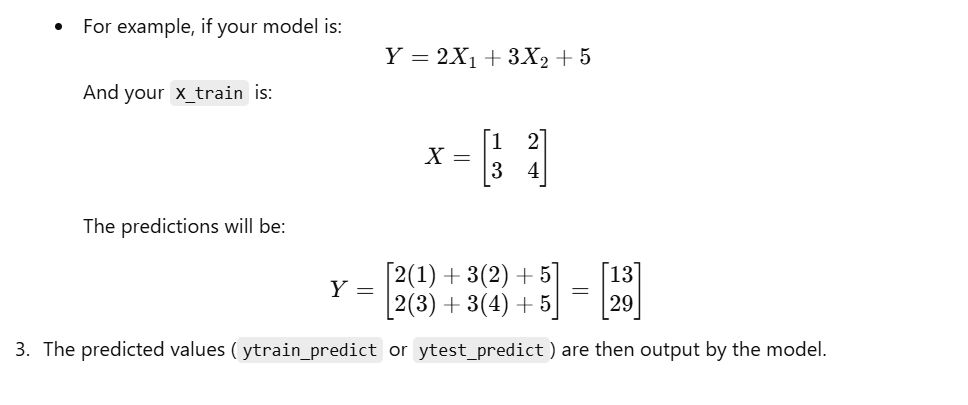

Why Don’t We Pass Y_train or Y_test?

We’re Evaluating the Model:

The point of model.predict() is to see how well the model performs on unseen data.

Y_train and Y_test are only used for comparison later (e.g., calculating RMSE or accuracy).

Features vs. Target Separation:

During both training and prediction, the model only works with features (X). The actual targets (Y) are just used for training (to calculate errors and update weights) or evaluation.

** Key Points: **

X_train and X_test contain all the information the model needs to make predictions.

Y_train and Y_test are the actual true values, which we use to measure the model’s accuracy later.

This separation ensures that the model doesn't "cheat" by seeing the true labels during prediction.

# **Modeling & Evaluation **

1. Linear Regression

In [24]:
# loading the linear regression model
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, Y_train)

Y_pred = lr.predict(X_test)

Model Evaluation

In [25]:
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
print("RMSE:", rmse)

RMSE: 2.2459912395277493


Visualize the actual prices and Predicted prices

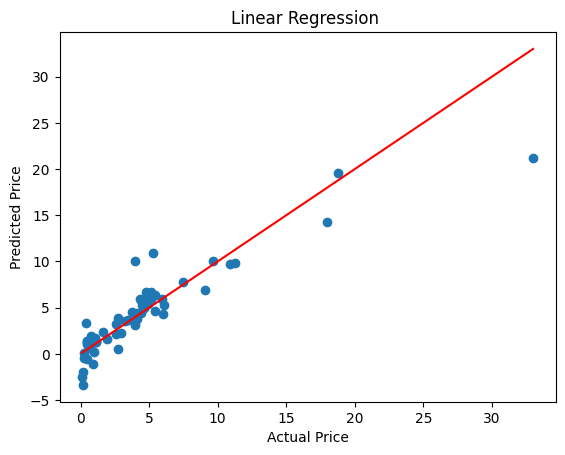

In [26]:
plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression ")

# الخط المثالي
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         color='red')

plt.show()

2. Lasso Regression

In [27]:
# loading the linear regression model
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.6)
lasso.fit(X_train, Y_train)
Y_pred_lasso = lasso.predict(X_test)

print("R2:", r2_score(Y_test, Y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_pred_lasso)))

R2: 0.8009438301868054
RMSE: 2.3784010521746333


Model Evaluation

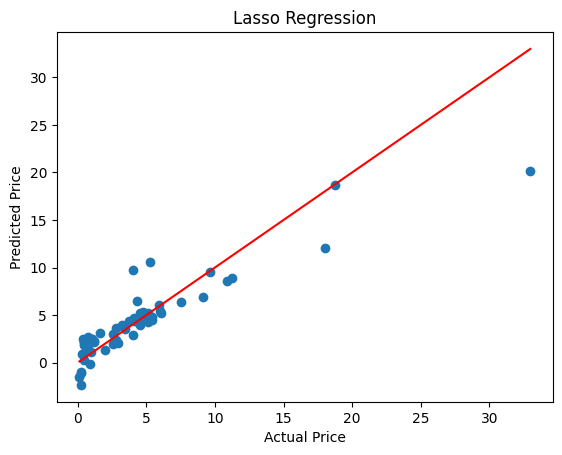

In [28]:
plt.scatter(Y_test, Y_pred_lasso)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         color='red')

plt.title("Lasso Regression")
plt.show()

In [29]:
#  now use ridge
ridge = Ridge(alpha=0.2)
ridge.fit(X_train, Y_train)
Y_pred_ridge = ridge.predict(X_test)
print("R2:", r2_score(Y_test, Y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_pred_ridge)))

R2: 0.8223395069593391
RMSE: 2.2469463254709763


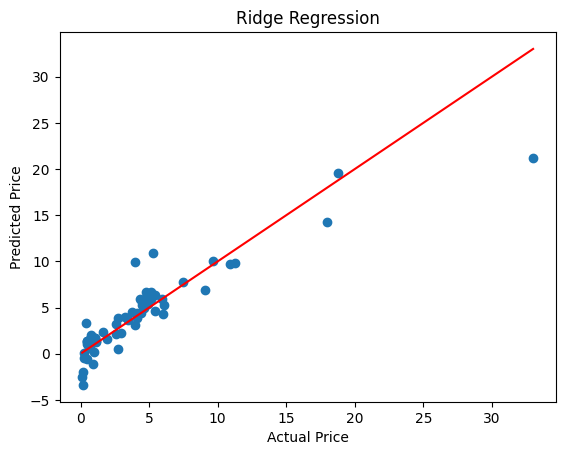

In [30]:
# display the results as well

plt.scatter(Y_test, Y_pred_ridge)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         color='red')

plt.title("Ridge Regression")
plt.show()

# Good job _ upload ur work on kaggle and on github:::::

In [31]:
import pickle

pickle.dump(lr, open('car_price_model.pkl', 'wb'))

In [33]:
X.columns

Index(['Year', 'Present_Price', 'Kms_Driven', 'Owner', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual'],
      dtype='object')